<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter3_Working_with_Numerical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 - Working with Numerical Data

Notebook ini membahas teknik preprocessing untuk data numerik menggunakan scikit-learn.  
Fokus utama chapter ini adalah bagaimana menyiapkan fitur numerik agar lebih sesuai untuk proses pembelajaran model machine learning.

Materi yang dibahas:
1. Melihat karakteristik data numerik
2. Standardization dengan `StandardScaler`
3. Min-Max scaling dengan `MinMaxScaler`
4. Normalization dengan `Normalizer`
5. Discretization / binning numerik
6. Transformasi distribusi data
7. Deteksi outlier sederhana dengan z-score
8. Perbandingan hasil preprocessing

## 1. Import Library

Pada chapter ini kita akan memakai:
- `numpy` dan `pandas` untuk manipulasi data
- `matplotlib` dan `seaborn` untuk visualisasi
- `scikit-learn` untuk preprocessing numerik
- dataset `wine` sebagai contoh data numerik multikelas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    Normalizer,
    KBinsDiscretizer,
    PowerTransformer
)

# Supaya output angka lebih rapi
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Load Dataset

Kita menggunakan dataset **Wine** dari scikit-learn.  
Dataset ini berisi fitur kimia dari beberapa jenis wine, misalnya:
- alcohol
- malic_acid
- ash
- magnesium
- color_intensity
- proline

Target pada dataset ini adalah kelas wine.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Shape fitur :", X.shape)
print("Shape target:", y.shape)
print("\n5 baris pertama data:")
display(X.head())

print("\nDistribusi target:")
print(y.value_counts().sort_index())

Shape fitur : (178, 13)
Shape target: (178,)

5 baris pertama data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Distribusi target:
target
0    59
1    71
2    48
Name: count, dtype: int64


## 3. Memahami Data Numerik

Sebelum melakukan preprocessing, kita perlu memahami skala data.  
Pada data numerik, sering kali tiap fitur memiliki rentang yang sangat berbeda.

Contoh:
- `alcohol` mungkin berada di sekitar 10–15
- `proline` bisa ratusan sampai ribuan
- `color_intensity` bisa memiliki distribusi yang berbeda lagi

Perbedaan skala seperti ini dapat memengaruhi model, terutama model yang berbasis jarak atau optimisasi gradien.

In [3]:
print("Informasi dataset:")
print(X.info())

print("\nStatistik deskriptif:")
display(X.describe().T)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 4. Visualisasi Skala Antar Fitur

Di sini kita melihat beberapa fitur numerik untuk memahami bahwa skala antar kolom bisa sangat berbeda.

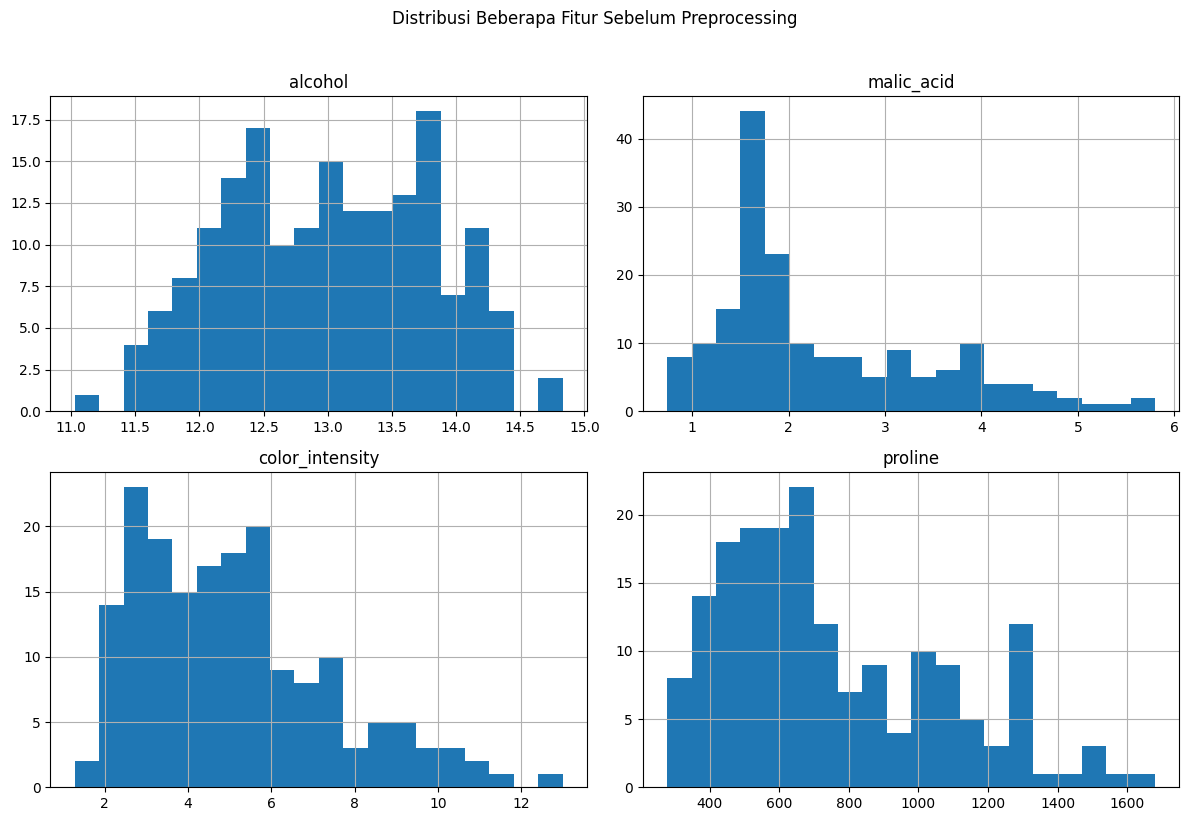

In [4]:
selected_cols = ["alcohol", "malic_acid", "color_intensity", "proline"]
X[selected_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribusi Beberapa Fitur Sebelum Preprocessing", y=1.02)
plt.tight_layout()
plt.show()

## 5. Standardization dengan StandardScaler

Standardization mengubah data sehingga:
- mean mendekati 0
- standar deviasi mendekati 1

Rumus umumnya:
\[
z = \frac{x - \mu}{\sigma}
\]

Teknik ini sering dipakai untuk:
- Logistic Regression
- SVM
- KNN
- PCA
- Neural Network

Karena model-model tersebut sensitif terhadap skala fitur.

In [5]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

X_std_df = pd.DataFrame(X_std, columns=X.columns)

print("5 baris pertama hasil StandardScaler:")
display(X_std_df.head())

5 baris pertama hasil StandardScaler:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [6]:
summary_std = pd.DataFrame({
    "mean_before": X.mean(),
    "std_before": X.std(),
    "mean_after_standard": X_std_df.mean(),
    "std_after_standard": X_std_df.std()
})

display(summary_std.head(10))

,mean_before,std_before,mean_after_standard,std_after_standard
alcohol,13.000618,0.811827,7.841418e-15,1.002821
malic_acid,2.336348,1.117146,2.444986e-16,1.002821
ash,2.366517,0.274344,-4.059175e-15,1.002821
alcalinity_of_ash,19.494944,3.339564,-7.110417e-17,1.002821
magnesium,99.741573,14.282484,-2.494883e-17,1.002821
total_phenols,2.295112,0.625851,-1.955365e-16,1.002821
flavanoids,2.029270,0.998859,9.443133e-16,1.002821
nonflavanoid_phenols,0.361854,0.124453,-4.178929e-16,1.002821
proanthocyanins,1.590899,0.572359,-1.540590e-15,1.002821
color_intensity,5.058090,2.318286,-4.129032e-16,1.002821


## 6. Visualisasi Hasil Standardization

Setelah standardization, skala fitur menjadi lebih seragam.  
Nilai setiap fitur kini berada di sekitar pusat yang sama, sehingga model lebih mudah memprosesnya.

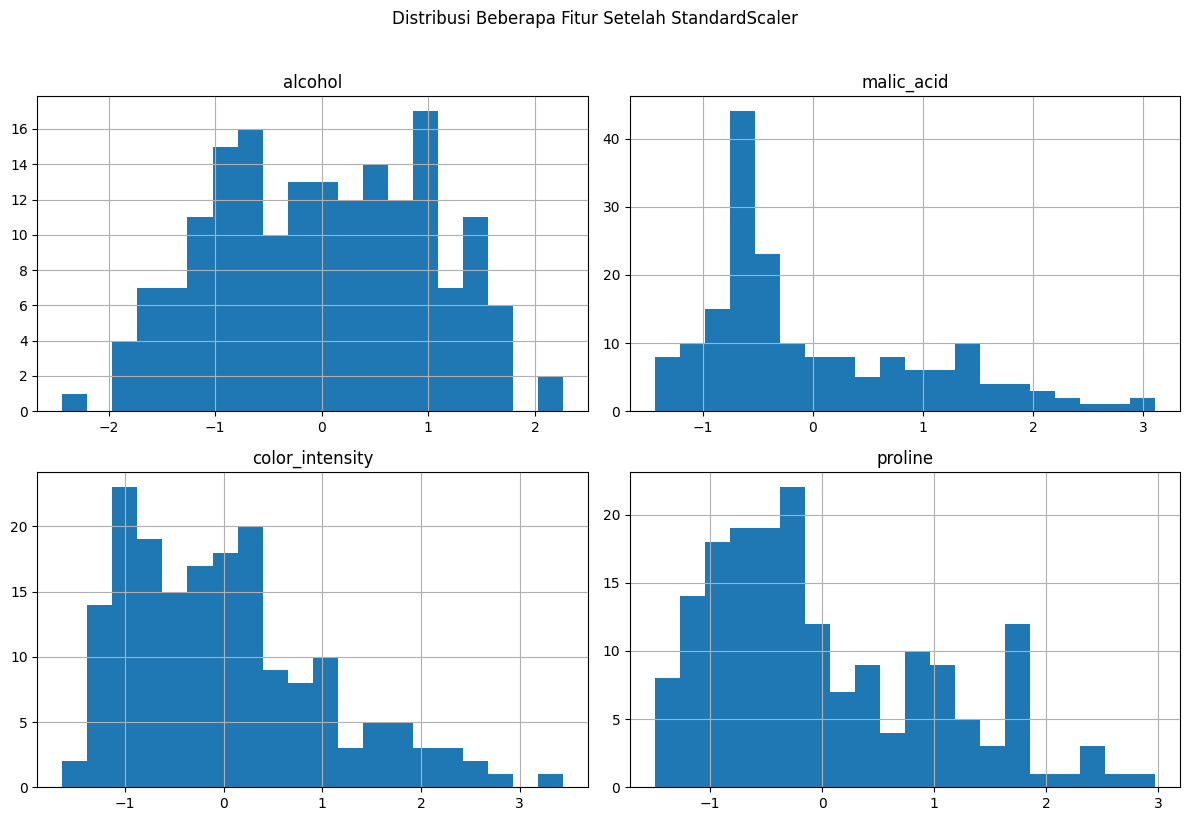

In [7]:
X_std_df[selected_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribusi Beberapa Fitur Setelah StandardScaler", y=1.02)
plt.tight_layout()
plt.show()

## 7. Min-Max Scaling dengan MinMaxScaler

Min-Max scaling mengubah data ke rentang tertentu, biasanya **0 sampai 1**.

Rumus:
\[
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

Kelebihan:
- mudah diinterpretasi
- menjaga bentuk distribusi relatif

Kekurangan:
- sensitif terhadap outlier, karena nilai minimum dan maksimum sangat berpengaruh.

In [8]:
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

X_mm_df = pd.DataFrame(X_mm, columns=X.columns)

print("5 baris pertama hasil MinMaxScaler:")
display(X_mm_df.head())

5 baris pertama hasil MinMaxScaler:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963


In [9]:
summary_mm = pd.DataFrame({
    "min_before": X.min(),
    "max_before": X.max(),
    "min_after_minmax": X_mm_df.min(),
    "max_after_minmax": X_mm_df.max()
})

display(summary_mm.head(10))

,min_before,max_before,min_after_minmax,max_after_minmax
alcohol,11.03,14.83,0.0,1.0
malic_acid,0.74,5.80,0.0,1.0
ash,1.36,3.23,0.0,1.0
alcalinity_of_ash,10.60,30.00,0.0,1.0
magnesium,70.00,162.00,0.0,1.0
total_phenols,0.98,3.88,0.0,1.0
flavanoids,0.34,5.08,0.0,1.0
nonflavanoid_phenols,0.13,0.66,0.0,1.0
proanthocyanins,0.41,3.58,0.0,1.0
color_intensity,1.28,13.00,0.0,1.0


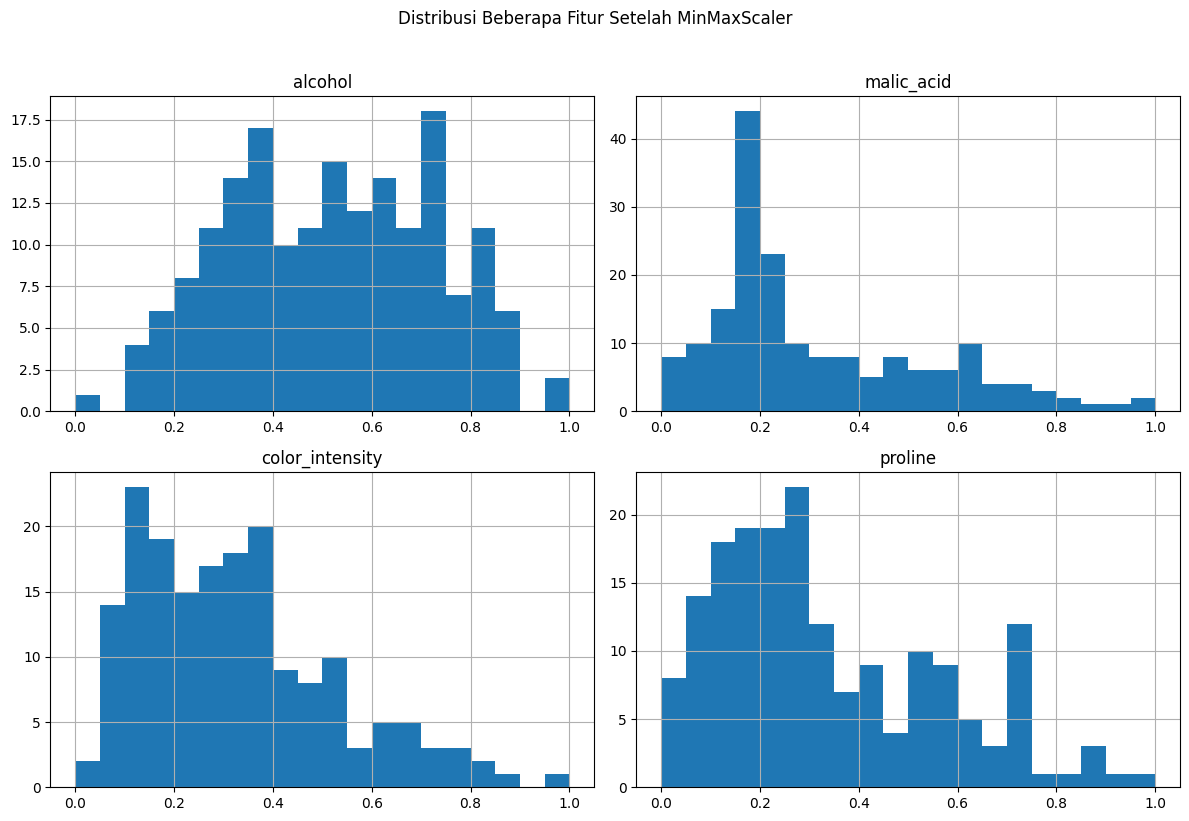

In [10]:
X_mm_df[selected_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribusi Beberapa Fitur Setelah MinMaxScaler", y=1.02)
plt.tight_layout()
plt.show()

## 8. Perbandingan StandardScaler vs MinMaxScaler

- **StandardScaler** cocok ketika model mengasumsikan data terpusat di sekitar nol.
- **MinMaxScaler** cocok ketika kita ingin semua fitur berada pada rentang yang sama, misalnya 0–1.

Pilihan scaler bergantung pada model, distribusi data, dan tujuan analisis.

In [11]:
comparison_scaling = pd.DataFrame({
    "original_alcohol": X["alcohol"].head(10).values,
    "standardized_alcohol": X_std_df["alcohol"].head(10).values,
    "minmax_alcohol": X_mm_df["alcohol"].head(10).values
})

display(comparison_scaling)

,original_alcohol,standardized_alcohol,minmax_alcohol
0,14.23,1.518613,0.842105
1,13.20,0.246290,0.571053
2,13.16,0.196879,0.560526
3,14.37,1.691550,0.878947
4,13.24,0.295700,0.581579
5,14.20,1.481555,0.834211
6,14.39,1.716255,0.884211
7,14.06,1.308617,0.797368
8,14.83,2.259772,1.000000
9,13.86,1.061565,0.744737


## 9. Normalization dengan Normalizer

Berbeda dengan scaler sebelumnya, **Normalizer** bekerja per baris / per sampel, bukan per kolom.

Tujuannya adalah membuat setiap sampel memiliki norma tertentu, biasanya norma L2 = 1.

Normalizer sering digunakan pada:
- data teks (TF-IDF vectors)
- data dengan fokus pada arah vektor, bukan besar nilainya
- cosine similarity

Jadi, kalau StandardScaler dan MinMaxScaler menyesuaikan **fitur**, Normalizer menyesuaikan **sampel**.

In [12]:
normalizer = Normalizer()
X_norm = normalizer.fit_transform(X)

X_norm_df = pd.DataFrame(X_norm, columns=X.columns)

print("5 baris pertama hasil Normalizer:")
display(X_norm_df.head())

5 baris pertama hasil Normalizer:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.013264,0.001594,0.002265,0.014542,0.118383,0.002610,0.002852,0.000261,0.002135,0.005257,0.000969,0.003654,0.992738
1,0.012513,0.001687,0.002029,0.010617,0.094794,0.002512,0.002616,0.000246,0.001213,0.004152,0.000995,0.003223,0.995336
2,0.011063,0.001984,0.002245,0.015636,0.084906,0.002354,0.002724,0.000252,0.002362,0.004775,0.000866,0.002665,0.996176
3,0.009680,0.001314,0.001684,0.011317,0.076119,0.002593,0.002351,0.000162,0.001468,0.005254,0.000579,0.002324,0.996961
4,0.017775,0.003477,0.003853,0.028193,0.158418,0.003759,0.003611,0.000524,0.002443,0.005800,0.001396,0.003934,0.986753


In [13]:
# Menghitung panjang vektor (L2 norm) untuk beberapa sampel
norms = np.linalg.norm(X_norm, axis=1)

print("5 nilai norm pertama setelah Normalizer:")
print(norms[:5])

print("\nRata-rata norm:", norms.mean())

5 nilai norm pertama setelah Normalizer:
[1. 1. 1. 1. 1.]

Rata-rata norm: 1.0


## 10. Discretization / Binning Data Numerik

Kadang data numerik ingin diubah menjadi beberapa interval / bin.  
Contohnya:
- usia menjadi kelompok umur
- pendapatan menjadi kategori rendah / sedang / tinggi
- skor menjadi level tertentu

Di scikit-learn, hal ini bisa dilakukan dengan `KBinsDiscretizer`.

Beberapa strategi binning:
- `uniform` → lebar interval sama
- `quantile` → jumlah data tiap bin kurang lebih sama
- `kmeans` → berdasarkan pola cluster nilai

In [14]:
feature_example = X[["alcohol"]].copy()

kbins = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
alcohol_binned = kbins.fit_transform(feature_example)

binned_df = pd.DataFrame({
    "alcohol_original": feature_example["alcohol"],
    "alcohol_bin": alcohol_binned.flatten().astype(int)
})

display(binned_df.head(15))

,alcohol_original,alcohol_bin
0,14.23,3
1,13.20,2
2,13.16,2
3,14.37,3
4,13.24,2
5,14.20,3
6,14.39,3
7,14.06,3
8,14.83,3
9,13.86,3


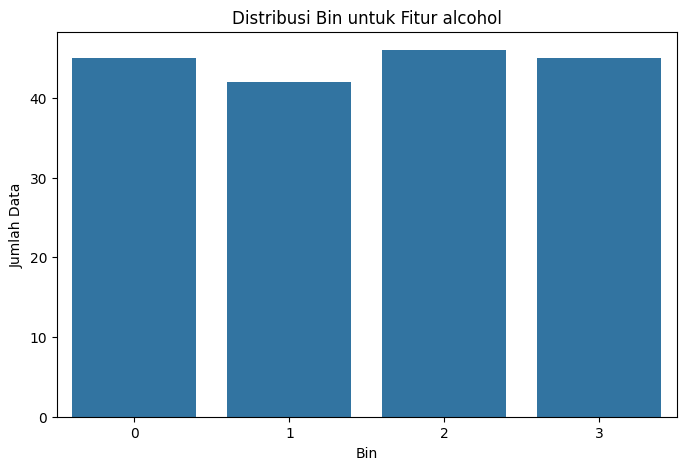

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x=binned_df["alcohol_bin"])
plt.title("Distribusi Bin untuk Fitur alcohol")
plt.xlabel("Bin")
plt.ylabel("Jumlah Data")
plt.show()

## 11. Membandingkan Nilai Asli dan Binned

Binning dapat membantu:
- menyederhanakan pola
- mengurangi efek noise kecil
- membuat fitur lebih mudah diinterpretasikan

Namun, terlalu banyak bin atau terlalu sedikit bin bisa menyebabkan hilangnya informasi.

In [16]:
display(
    binned_df.sort_values("alcohol_original").head(20)
)

,alcohol_original,alcohol_bin
115,11.03,0
113,11.41,0
120,11.45,0
110,11.46,0
121,11.56,0
109,11.61,0
94,11.62,0
88,11.64,0
87,11.65,0
75,11.66,0


## 12. Transformasi Distribusi dengan PowerTransformer

Beberapa fitur numerik memiliki distribusi yang sangat skewed (miring).  
Transformasi distribusi dilakukan agar data lebih mendekati distribusi yang stabil dan lebih mudah dipelajari model.

Salah satu transformasi yang umum adalah:
- **Yeo-Johnson**
- **Box-Cox** (hanya untuk data positif)

Di sini kita gunakan `PowerTransformer(method="yeo-johnson")`.

In [17]:
pt = PowerTransformer(method="yeo-johnson")
X_pt = pt.fit_transform(X)

X_pt_df = pd.DataFrame(X_pt, columns=X.columns)

print("5 baris pertama hasil PowerTransformer:")
display(X_pt_df.head())

5 baris pertama hasil PowerTransformer:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.530388,-0.435463,0.210464,-1.180400,1.690749,0.819950,1.027153,-0.609851,1.202701,0.451450,0.368811,2.037232,1.062541
1,0.238381,-0.338701,-0.839064,-2.663167,0.188126,0.591646,0.747647,-0.806373,-0.490487,-0.110974,0.412391,1.150327,1.029743
2,0.188751,0.318077,1.119290,-0.243437,0.261461,0.819950,1.192395,-0.421141,1.925646,0.467301,0.325202,0.779080,1.307868
3,1.708049,-0.121469,0.471827,-0.799464,1.020463,2.331036,1.419054,-1.011162,1.038972,1.182895,-0.420745,1.232761,1.810007
4,0.288052,0.523699,1.903702,0.472612,1.282104,0.819950,0.681647,0.342097,0.471707,-0.141340,0.368811,0.405810,0.188985


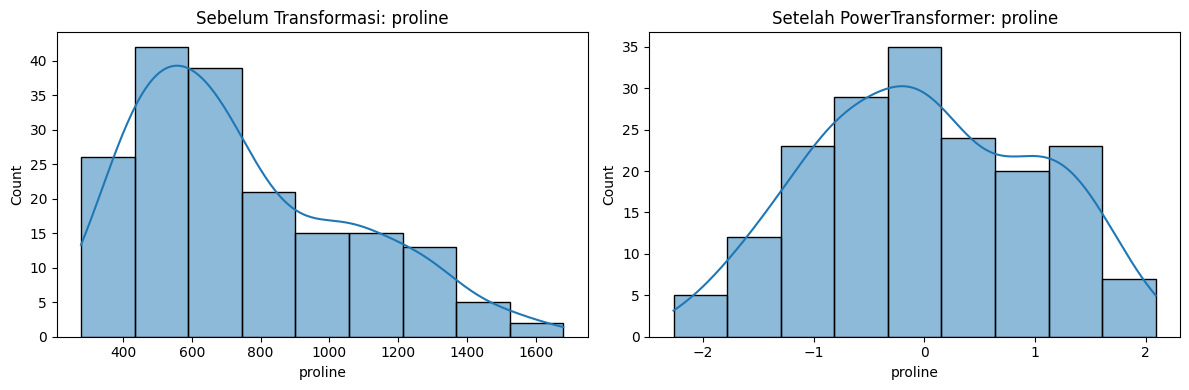

In [18]:
feature_to_plot = "proline"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(X[feature_to_plot], kde=True, ax=axes[0])
axes[0].set_title(f"Sebelum Transformasi: {feature_to_plot}")

sns.histplot(X_pt_df[feature_to_plot], kde=True, ax=axes[1])
axes[1].set_title(f"Setelah PowerTransformer: {feature_to_plot}")

plt.tight_layout()
plt.show()

## 13. Deteksi Outlier Sederhana dengan Z-Score

Outlier adalah observasi yang nilainya jauh dari mayoritas data.  
Outlier dapat memengaruhi:
- rata-rata
- standar deviasi
- scaling
- model yang sensitif terhadap nilai ekstrem

Salah satu pendekatan sederhana adalah menggunakan **z-score**:
\[
z = \frac{x - \mu}{\sigma}
\]

Data dengan |z| > 3 sering dianggap outlier.

In [19]:
# Pilih satu fitur contoh
feature_name = "proline"

z_scores = (X[feature_name] - X[feature_name].mean()) / X[feature_name].std()
outliers = X[np.abs(z_scores) > 3]

print(f"Jumlah outlier pada fitur '{feature_name}' berdasarkan |z| > 3: {len(outliers)}")
display(outliers[[feature_name]].head(10))

Jumlah outlier pada fitur 'proline' berdasarkan |z| > 3: 0


,proline


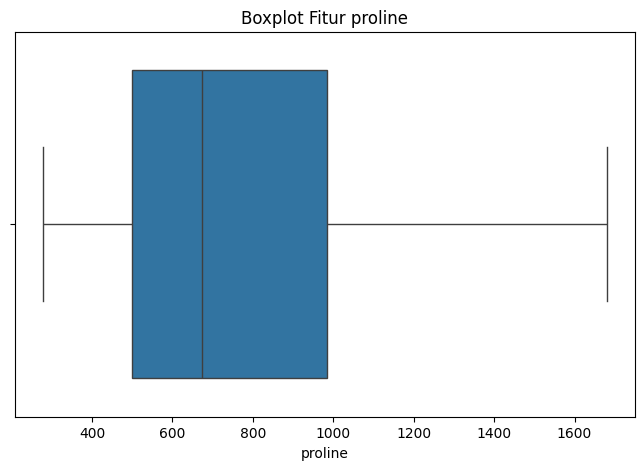

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=X[feature_name])
plt.title(f"Boxplot Fitur {feature_name}")
plt.show()

## 14. Ringkasan Perbandingan Beberapa Teknik

Pada bagian ini kita buat tabel ringkas untuk melihat perbedaan hasil preprocessing pada satu fitur.

In [21]:
feature_compare = "color_intensity"

comparison_df = pd.DataFrame({
    "original": X[feature_compare].head(10).values,
    "standardized": X_std_df[feature_compare].head(10).values,
    "minmax": X_mm_df[feature_compare].head(10).values,
    "normalized": X_norm_df[feature_compare].head(10).values,
    "power_transformed": X_pt_df[feature_compare].head(10).values
})

display(comparison_df)

,original,standardized,minmax,normalized,power_transformed
0,5.64,0.251717,0.372014,0.005257,0.451450
1,4.38,-0.293321,0.264505,0.004152,-0.110974
2,5.68,0.269020,0.375427,0.004775,0.467301
3,7.80,1.186068,0.556314,0.005254,1.182895
4,4.32,-0.319276,0.259386,0.005800,-0.141340
5,6.75,0.731870,0.466724,0.004641,0.855891
6,5.25,0.083015,0.338737,0.004058,0.291078
7,5.05,-0.003499,0.321672,0.003882,0.204440
8,5.20,0.061386,0.334471,0.004954,0.269712
9,7.22,0.935177,0.506826,0.006877,1.008024


## 15. Kapan Menggunakan Tiap Teknik?

### StandardScaler
Gunakan ketika:
- model sensitif terhadap skala fitur
- data ingin dipusatkan di sekitar nol

### MinMaxScaler
Gunakan ketika:
- ingin fitur berada pada rentang tertentu
- ingin mempertahankan interpretasi relatif minimum-maksimum

### Normalizer
Gunakan ketika:
- fokus pada arah vektor per sampel
- banyak dipakai pada data teks atau cosine similarity

### KBinsDiscretizer
Gunakan ketika:
- ingin mengubah fitur numerik menjadi kategori interval
- ingin menyederhanakan pola numerik

### PowerTransformer
Gunakan ketika:
- distribusi data sangat skewed
- ingin distribusi fitur lebih stabil

## 16. Kesimpulan

Pada chapter ini, kita mempelajari bahwa preprocessing numerik sangat penting sebelum model machine learning dilatih.

Poin utama:
1. Fitur numerik sering memiliki skala yang berbeda, sehingga perlu penyesuaian.
2. `StandardScaler` mengubah data agar memiliki mean sekitar 0 dan standar deviasi sekitar 1.
3. `MinMaxScaler` memetakan nilai ke rentang tertentu, biasanya 0–1.
4. `Normalizer` menormalkan setiap sampel, bukan setiap fitur.
5. `KBinsDiscretizer` mengubah nilai numerik menjadi beberapa interval.
6. `PowerTransformer` membantu menangani distribusi yang skewed.
7. Outlier perlu diperhatikan karena dapat memengaruhi preprocessing dan performa model.

Dengan preprocessing yang tepat, data numerik menjadi lebih siap untuk dipelajari oleh model machine learning.